In [1]:
# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 2: SQL Server Connection

server = 'Arup\SQLEXPRESS'
database = 'upi_analysis_db'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("Connection successful!")

Connection successful!


In [3]:
# Step 3: Load all 7 tables
customer_df     = pd.read_sql('SELECT * FROM vw_clean_customer', engine)
transaction_df  = pd.read_sql('SELECT * FROM dbo.upi_transaction_history', engine)
merchant_df     = pd.read_sql('SELECT * FROM dbo.merchant_info', engine)
device_df       = pd.read_sql('SELECT * FROM dbo.device_info', engine)
upi_account_df  = pd.read_sql('SELECT * FROM dbo.upi_account_details', engine)
fraud_df        = pd.read_sql('SELECT * FROM dbo.fraud_alert_history', engine)
feedback_df     = pd.read_sql('SELECT * FROM dbo.customer_feedback', engine)

print("All tables loaded!")

All tables loaded!


In [4]:
# Step 4: Verify row counts
print("\nRow Counts:")
print(f"customer_master      : {len(customer_df)}")
print(f"transaction_history  : {len(transaction_df)}")
print(f"merchant_info        : {len(merchant_df)}")
print(f"device_info          : {len(device_df)}")
print(f"upi_account_details  : {len(upi_account_df)}")
print(f"fraud_alert_history  : {len(fraud_df)}")
print(f"customer_feedback    : {len(feedback_df)}")


Row Counts:
customer_master      : 10000
transaction_history  : 100000
merchant_info        : 500
device_info          : 12000
upi_account_details  : 12000
fraud_alert_history  : 2000
customer_feedback    : 4000


In [5]:
# Check shape of all dataframes
print("Shape of all tables:")
print(f"customer_df     : {customer_df.shape}")
print(f"transaction_df  : {transaction_df.shape}")
print(f"merchant_df     : {merchant_df.shape}")
print(f"device_df       : {device_df.shape}")
print(f"upi_account_df  : {upi_account_df.shape}")
print(f"fraud_df        : {fraud_df.shape}")
print(f"feedback_df     : {feedback_df.shape}")

Shape of all tables:
customer_df     : (10000, 10)
transaction_df  : (100000, 15)
merchant_df     : (500, 6)
device_df       : (12000, 6)
upi_account_df  : (12000, 6)
fraud_df        : (2000, 7)
feedback_df     : (4000, 7)


In [6]:
#check data types of all tables
print(customer_df.info())
print(transaction_df.info())
print(merchant_df.info())
print(device_df.info())
print(upi_account_df.info())
print(fraud_df.info())
print(feedback_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  object 
 1   full_name         10000 non-null  object 
 2   age               10000 non-null  int64  
 3   gender            10000 non-null  object 
 4   region            10000 non-null  object 
 5   date_joined       10000 non-null  object 
 6   is_business_user  10000 non-null  bool   
 7   risk_score        10000 non-null  float64
 8   mobile_number     10000 non-null  object 
 9   mobile_status     10000 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 713.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 

In [7]:
# Correct data types of  table        column
                     #  customer     date_joined 
                     #  merchant     onboard_date
                     #  upi_account  date_added
                     #  feedback     date_submitted

In [8]:
# Fix date columns
customer_df['date_joined']       = pd.to_datetime(customer_df['date_joined'])
merchant_df['onboard_date']      = pd.to_datetime(merchant_df['onboard_date'])
upi_account_df['date_added']     = pd.to_datetime(upi_account_df['date_added'])
feedback_df['date_submitted']    = pd.to_datetime(feedback_df['date_submitted'])

In [9]:
# Verify fixes
print("date_joined   :", customer_df['date_joined'].dtype)
print("onboard_date  :", merchant_df['onboard_date'].dtype)
print("date_added    :", upi_account_df['date_added'].dtype)
print("date_submitted:", feedback_df['date_submitted'].dtype)

date_joined   : datetime64[ns]
onboard_date  : datetime64[ns]
date_added    : datetime64[ns]
date_submitted: datetime64[ns]


In [10]:
# Check NULL values in all tables
print("NULL Values Summary:")
print("\nCustomer:")
print(customer_df.isnull().sum())
print("\nTransaction:")
print(transaction_df.isnull().sum())
print("\nMerchant:")
print(merchant_df.isnull().sum())
print("\nDevice:")
print(device_df.isnull().sum())
print("\nUPI Account:")
print(upi_account_df.isnull().sum())
print("\nFraud Alerts:")
print(fraud_df.isnull().sum())
print("\nFeedback:")
print(feedback_df.isnull().sum())

NULL Values Summary:

Customer:
customer_id         0
full_name           0
age                 0
gender              0
region              0
date_joined         0
is_business_user    0
risk_score          0
mobile_number       0
mobile_status       0
dtype: int64

Transaction:
transaction_id          0
upi_id                  0
customer_id             0
timestamp               0
amount                  0
transaction_type        0
merchant_id         69851
counterparty_upi        0
status                  0
device_id               0
device_type             0
channel                 0
fraud_flag              0
reversal_flag           0
failure_reason          0
dtype: int64

Merchant:
merchant_id      0
merchant_name    0
merchant_type    0
region           0
onboard_date     0
risk_score       0
dtype: int64

Device:
device_id      0
customer_id    0
device_type    0
app_version    0
is_rooted      0
last_active    0
dtype: int64

UPI Account:
upi_id          0
customer_id     0
bank_n

In [11]:
# Confirm merchant_id NULLs are peer to peer transactions
print("Transactions without merchant (peer-to-peer):")
print(transaction_df[transaction_df['merchant_id'].isnull()]['transaction_type'].value_counts())

# Confirm resolution_date NULLs are unresolved alerts
print("\nUnresolved alerts:")
print(fraud_df[fraud_df['resolution_date'].isnull()]['resolved'].value_counts())

Transactions without merchant (peer-to-peer):
transaction_type
send       35032
receive    34819
Name: count, dtype: int64

Unresolved alerts:
resolved
False    248
Name: count, dtype: int64


# Visualizations

In [12]:
# ============================================
# KPI SUMMARY
# ============================================

# Total Transactions
total_transactions = len(transaction_df)

# Total Transaction Amount
total_amount = transaction_df['amount'].sum()

# Success Rate
success_rate = (
    (transaction_df['status'] == 'success').mean()
) * 100

# Failure Rate
failure_rate = (
    (transaction_df['status'] == 'failed').mean()
) * 100

# Fraud Rate
fraud_rate = (
    transaction_df['fraud_flag'].mean()
) * 100

# Average Transaction Amount
avg_amount = transaction_df['amount'].mean()

# Print KPIs
print("=" * 40)
print("           KPI SUMMARY")
print("=" * 40)

print(f"Total Transactions     : {total_transactions:,}")
print(f"Total Amount           : ₹{total_amount:,.2f}")
print(f"Average Amount         : ₹{avg_amount:,.2f}")

print("-" * 40)

print(f"Success Rate           : {success_rate:.2f}%")
print(f"Failure Rate           : {failure_rate:.2f}%")
print(f"Fraud Rate             : {fraud_rate:.2f}%")

print("=" * 40)

           KPI SUMMARY
Total Transactions     : 100,000
Total Amount           : ₹4,241,774.26
Average Amount         : ₹42.42
----------------------------------------
Success Rate           : 92.14%
Failure Rate           : 5.87%
Fraud Rate             : 2.00%


1️⃣ Transaction Status Distribution

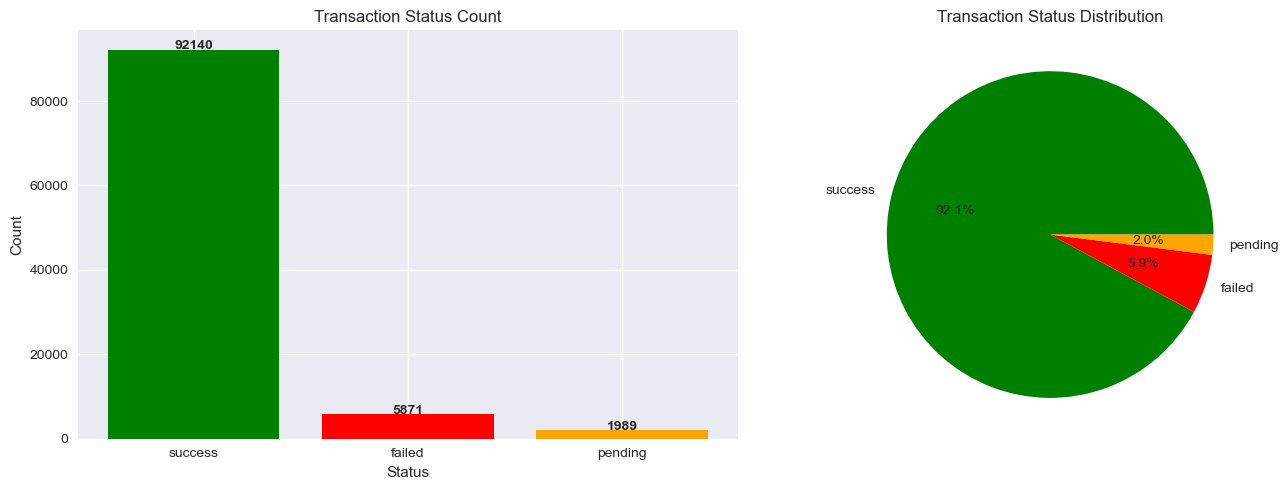

status
success    92140
failed      5871
pending     1989
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
status_counts = transaction_df['status'].value_counts()

# Bar chart
axes[0].bar(status_counts.index, status_counts.values,
            color=['green', 'red', 'orange'])
axes[0].set_title('Transaction Status Count')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=['green', 'red', 'orange'])
axes[1].set_title('Transaction Status Distribution')

plt.tight_layout()
plt.savefig('transaction_status.png', dpi=150, bbox_inches='tight')
plt.show()
print(status_counts)

2️⃣ Monthly Transaction Trend

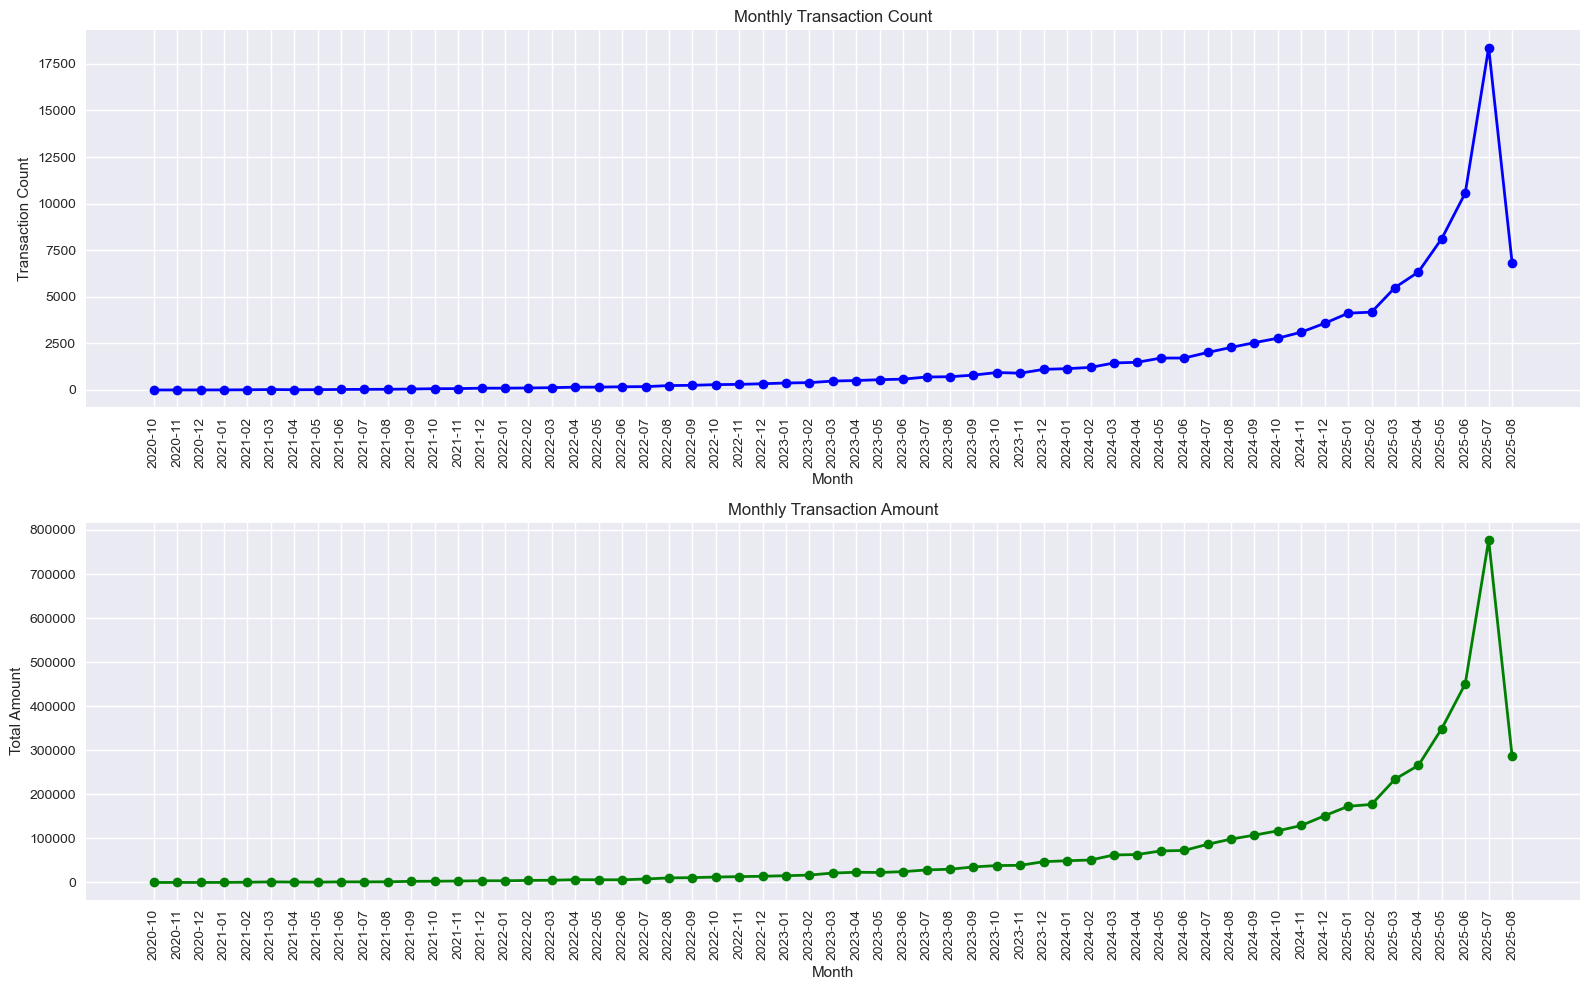

In [14]:
monthly = transaction_df.groupby([
    transaction_df['timestamp'].dt.year.rename('year'),
    transaction_df['timestamp'].dt.month.rename('month')
]).agg(
    total_txn    = ('transaction_id', 'count'),
    total_amount = ('amount', 'sum'),
    fraud_count  = ('fraud_flag', 'sum')
).reset_index()

monthly['year_month'] = monthly['year'].astype(str) + '-' + \
                        monthly['month'].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Transaction count trend
axes[0].plot(monthly['year_month'], monthly['total_txn'],
             marker='o', color='blue', linewidth=2)
axes[0].set_title('Monthly Transaction Count')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Transaction Count')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True)

# Transaction amount trend
axes[1].plot(monthly['year_month'], monthly['total_amount'],
             marker='o', color='green', linewidth=2)
axes[1].set_title('Monthly Transaction Amount')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Amount')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

3️⃣ Transaction Amount Distribution

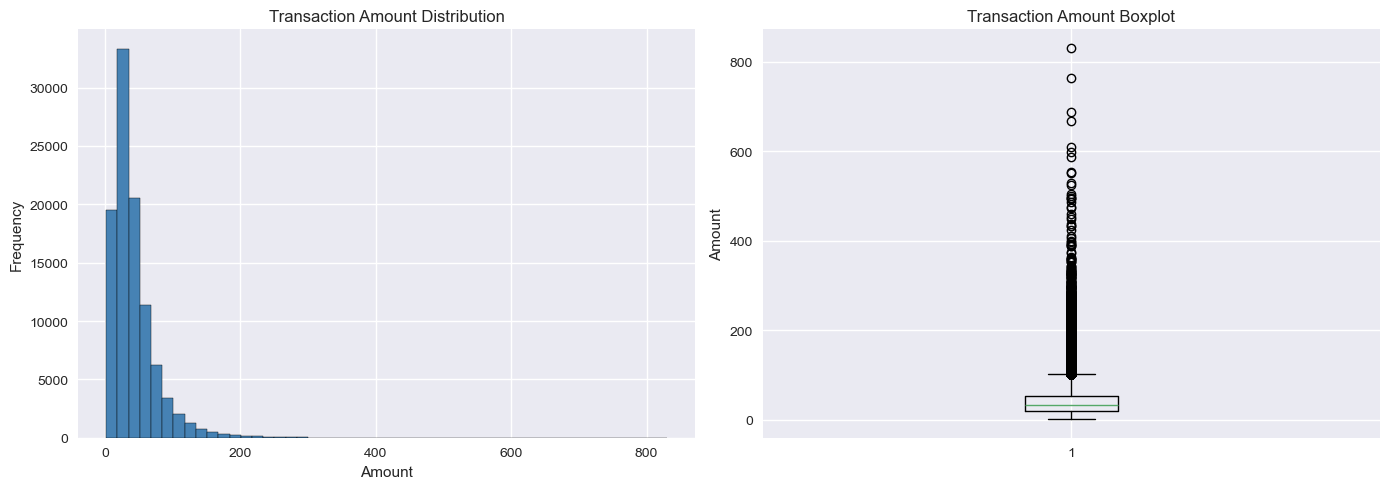

Amount Statistics:
count    100000.000000
mean         42.417743
std          34.186004
min           1.620000
25%          20.690000
50%          33.090000
75%          53.170000
max         830.460000
Name: amount, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(transaction_df['amount'], bins=50,
             color='steelblue', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(transaction_df['amount'], vert=True)
axes[1].set_title('Transaction Amount Boxplot')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Amount Statistics:")
print(transaction_df['amount'].describe())

4️⃣ Transaction Type & Channel

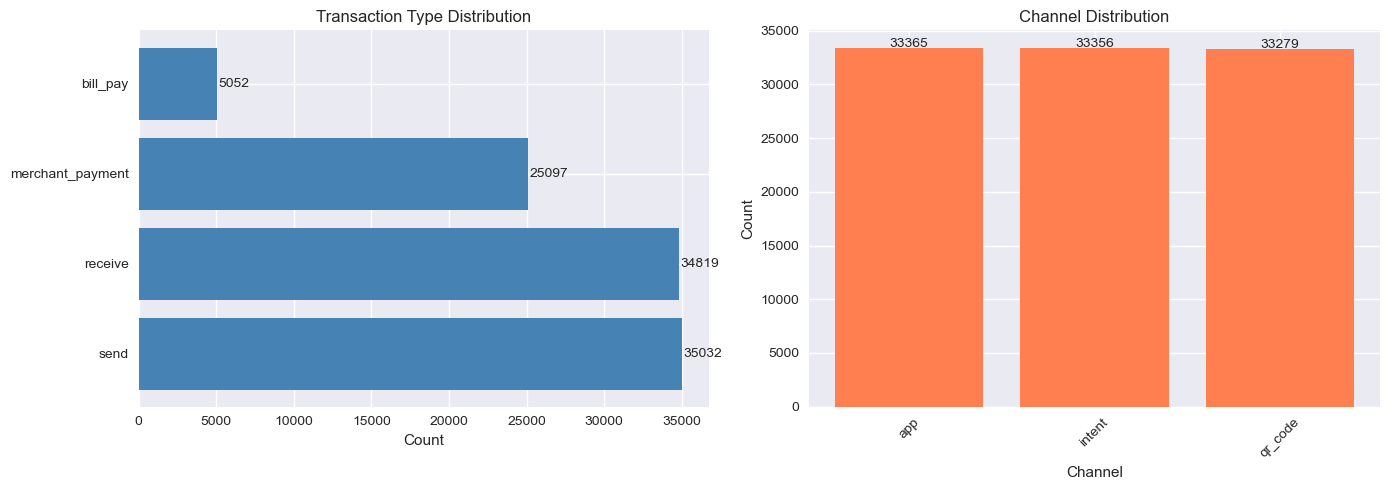

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type
txn_type = transaction_df['transaction_type'].value_counts()
axes[0].barh(txn_type.index, txn_type.values, color='steelblue')
axes[0].set_title('Transaction Type Distribution')
axes[0].set_xlabel('Count')
for i, v in enumerate(txn_type.values):
    axes[0].text(v + 100, i, str(v), va='center')

# Channel distribution
channel = transaction_df['channel'].value_counts()
axes[1].bar(channel.index, channel.values, color='coral')
axes[1].set_title('Channel Distribution')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(channel.values):
    axes[1].text(i, v + 100, str(v), ha='center')

plt.tight_layout()
plt.savefig('txn_type_channel.png', dpi=150, bbox_inches='tight')
plt.show()

5️⃣ Fraud Analysis

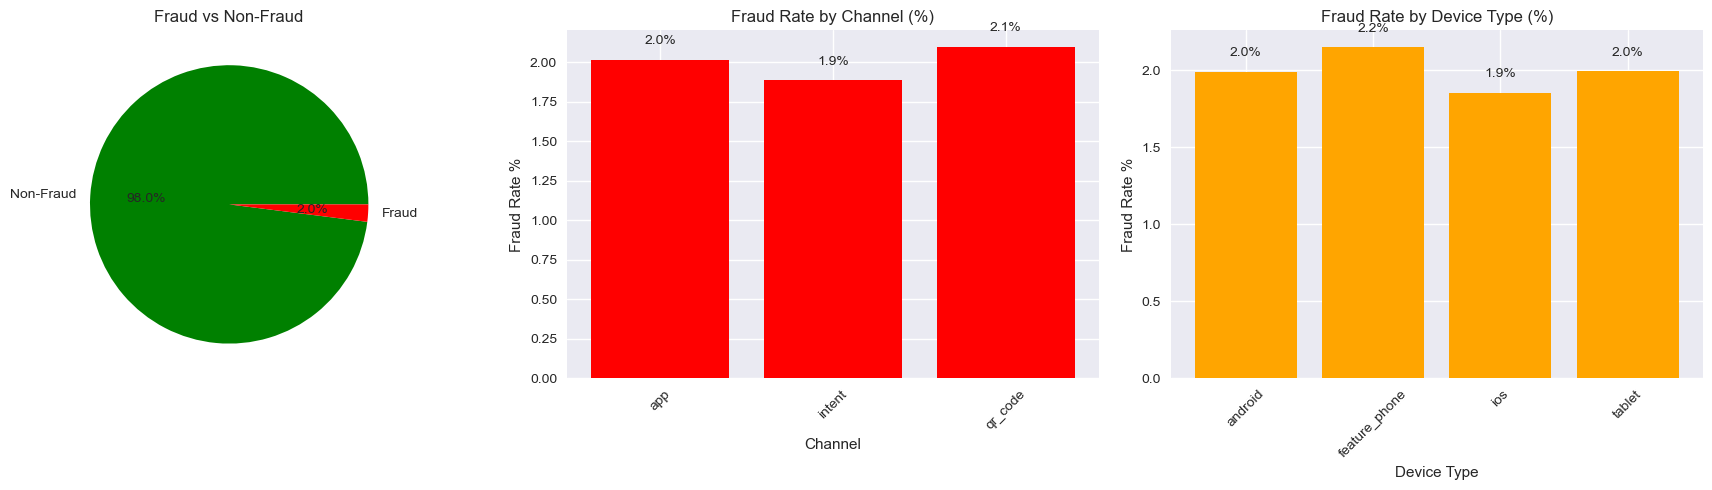

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud vs Non-Fraud
fraud_counts = transaction_df['fraud_flag'].value_counts()
axes[0].pie(fraud_counts.values,
            labels=['Non-Fraud', 'Fraud'],
            autopct='%1.1f%%',
            colors=['green', 'red'])
axes[0].set_title('Fraud vs Non-Fraud')

# Fraud by channel
fraud_channel = transaction_df.groupby('channel')['fraud_flag'].mean() * 100
axes[1].bar(fraud_channel.index, fraud_channel.values, color='red')
axes[1].set_title('Fraud Rate by Channel (%)')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Fraud Rate %')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_channel.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center')

# Fraud by device type
fraud_device = transaction_df.groupby('device_type')['fraud_flag'].mean() * 100
axes[2].bar(fraud_device.index, fraud_device.values, color='orange')
axes[2].set_title('Fraud Rate by Device Type (%)')
axes[2].set_xlabel('Device Type')
axes[2].set_ylabel('Fraud Rate %')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(fraud_device.values):
    axes[2].text(i, v + 0.1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

6️⃣ Customer Demographics

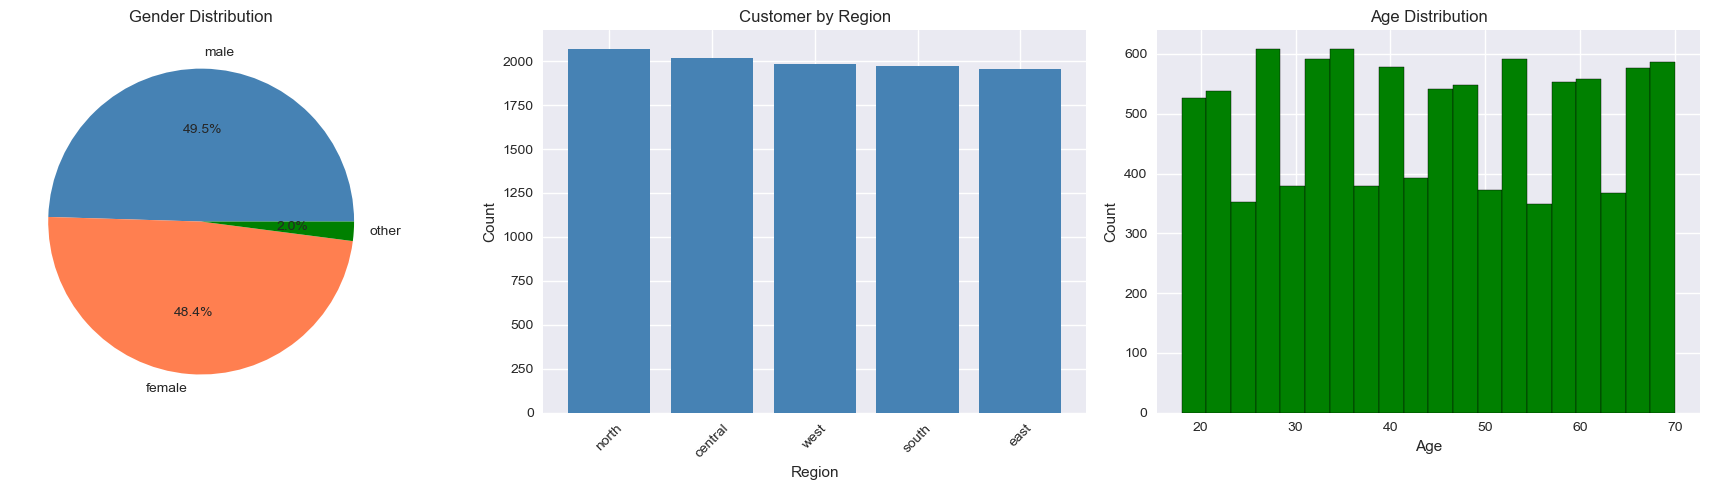

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender distribution
gender = customer_df['gender'].value_counts()
axes[0].pie(gender.values, labels=gender.index,
            autopct='%1.1f%%', colors=['steelblue', 'coral', 'green'])
axes[0].set_title('Gender Distribution')

# Region distribution
region = customer_df['region'].value_counts()
axes[1].bar(region.index, region.values, color='steelblue')
axes[1].set_title('Customer by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Age distribution
axes[2].hist(customer_df['age'], bins=20,
             color='green', edgecolor='black')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('customer_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

7️⃣ Risk Score Distribution

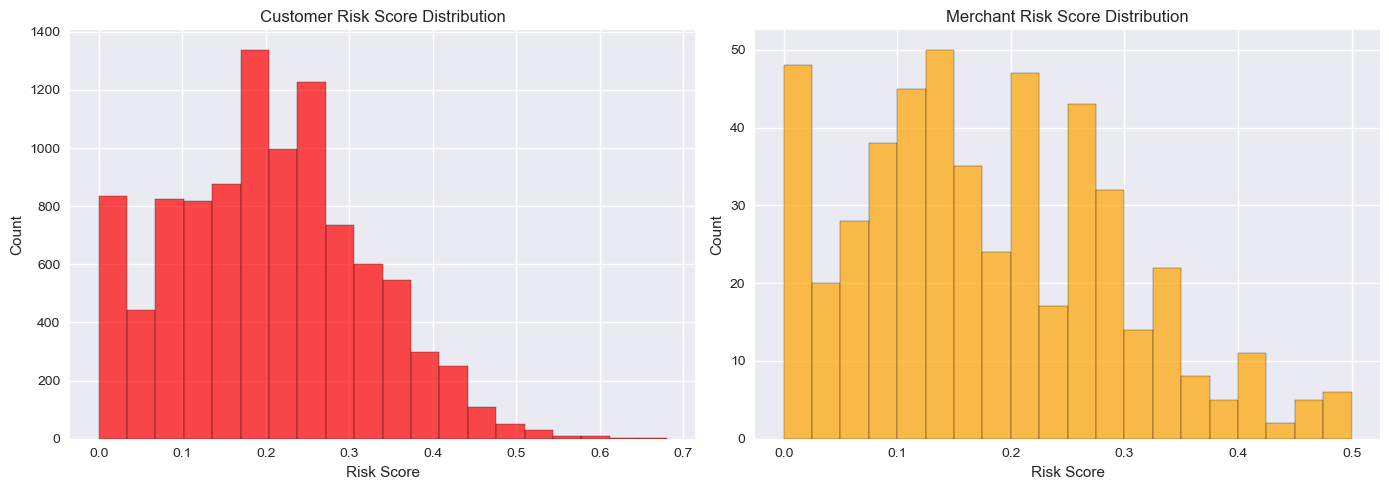

Customer Risk Score Stats:
count    10000.000000
mean         0.203477
std          0.115168
min          0.000000
25%          0.120000
50%          0.200000
75%          0.280000
max          0.680000
Name: risk_score, dtype: float64

Merchant Risk Score Stats:
count    500.000000
mean       0.179180
std        0.115722
min        0.000000
25%        0.090000
50%        0.170000
75%        0.260000
max        0.500000
Name: risk_score, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer risk score
axes[0].hist(customer_df['risk_score'], bins=20,
             color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('Customer Risk Score Distribution')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Count')

# Merchant risk score
axes[1].hist(merchant_df['risk_score'], bins=20,
             color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Merchant Risk Score Distribution')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Customer Risk Score Stats:")
print(customer_df['risk_score'].describe())
print("\nMerchant Risk Score Stats:")
print(merchant_df['risk_score'].describe())

8️⃣ Device Analysis

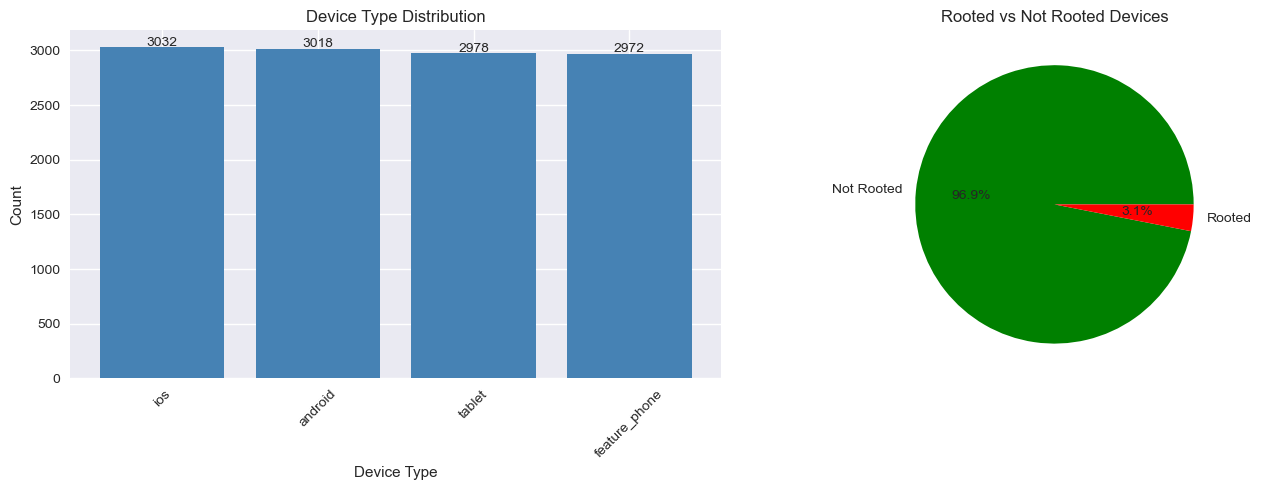

Fraud Rate by Rooted Status:
is_rooted
False     1.388014
True     20.687480
Name: fraud_flag, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device type distribution
device_type = device_df['device_type'].value_counts()
axes[0].bar(device_type.index, device_type.values, color='steelblue')
axes[0].set_title('Device Type Distribution')
axes[0].set_xlabel('Device Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(device_type.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Rooted vs not rooted
rooted = device_df['is_rooted'].value_counts()
axes[1].pie(rooted.values,
            labels=['Not Rooted', 'Rooted'],
            autopct='%1.1f%%',
            colors=['green', 'red'])
axes[1].set_title('Rooted vs Not Rooted Devices')

plt.tight_layout()
plt.savefig('device_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Rooted device fraud rate
rooted_fraud = transaction_df.merge(
    device_df[['device_id', 'is_rooted']],
    on='device_id', how='left'
)
print("Fraud Rate by Rooted Status:")
print(rooted_fraud.groupby('is_rooted')['fraud_flag'].mean() * 100)

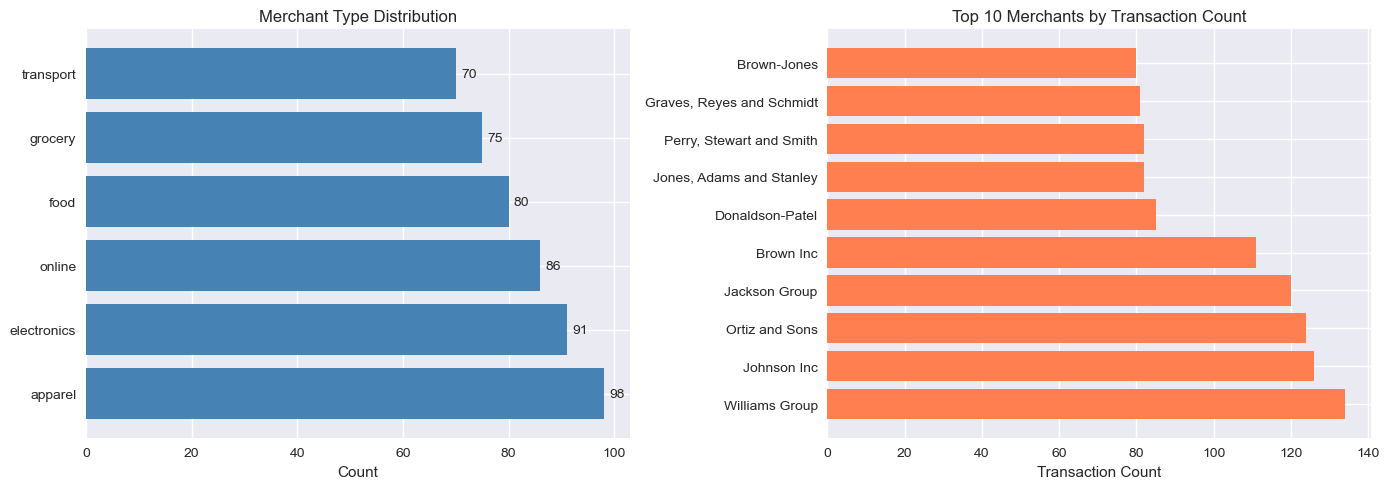

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merchant type distribution
merchant_type = merchant_df['merchant_type'].value_counts()
axes[0].barh(merchant_type.index, merchant_type.values, color='steelblue')
axes[0].set_title('Merchant Type Distribution')
axes[0].set_xlabel('Count')
for i, v in enumerate(merchant_type.values):
    axes[0].text(v + 1, i, str(v), va='center')

# Top 10 merchants by transaction count
top_merchants = transaction_df.merge(
    merchant_df[['merchant_id', 'merchant_name']],
    on='merchant_id', how='left'
).groupby('merchant_name')['transaction_id'].count()\
 .sort_values(ascending=False).head(10)

axes[1].barh(top_merchants.index, top_merchants.values, color='coral')
axes[1].set_title('Top 10 Merchants by Transaction Count')
axes[1].set_xlabel('Transaction Count')

plt.tight_layout()
plt.savefig('merchant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

🔟 Feedback Analysis

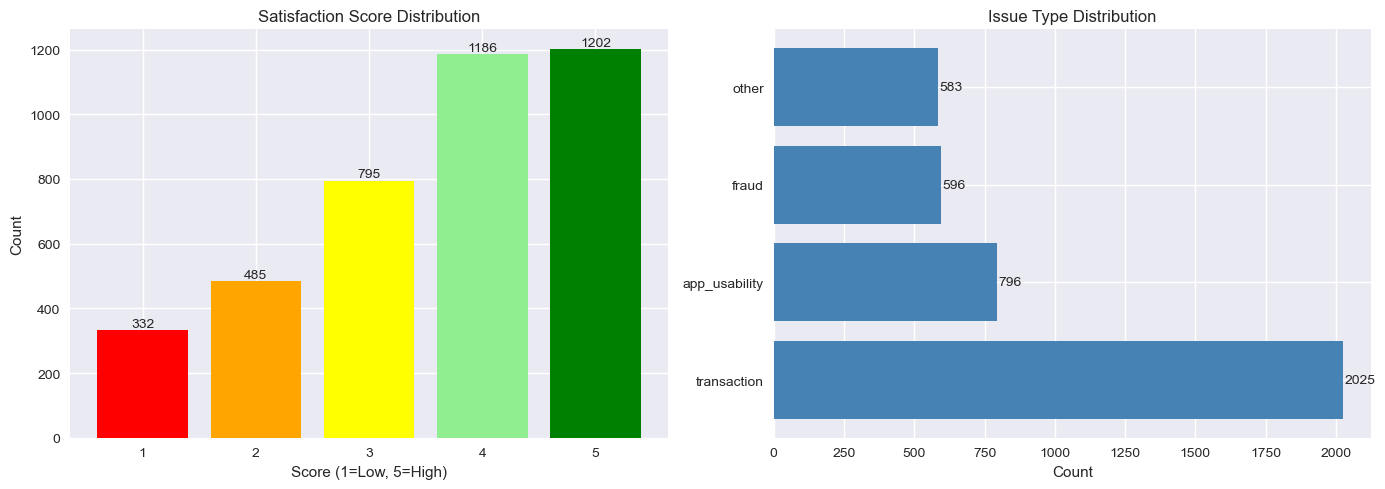

Average Satisfaction Score: 3.61


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction score distribution
satisfaction = feedback_df['satisfaction_score'].value_counts().sort_index()
axes[0].bar(satisfaction.index, satisfaction.values,
            color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
axes[0].set_title('Satisfaction Score Distribution')
axes[0].set_xlabel('Score (1=Low, 5=High)')
axes[0].set_ylabel('Count')
for i, v in enumerate(satisfaction.values):
    axes[0].text(i + 1, v + 10, str(v), ha='center')

# Issue type distribution
issue_type = feedback_df['issue_type'].value_counts()
axes[1].barh(issue_type.index, issue_type.values, color='steelblue')
axes[1].set_title('Issue Type Distribution')
axes[1].set_xlabel('Count')
for i, v in enumerate(issue_type.values):
    axes[1].text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.savefig('feedback_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average Satisfaction Score:", round(feedback_df['satisfaction_score'].mean(), 2))

1️⃣1️⃣ Fraud Alert Analysis

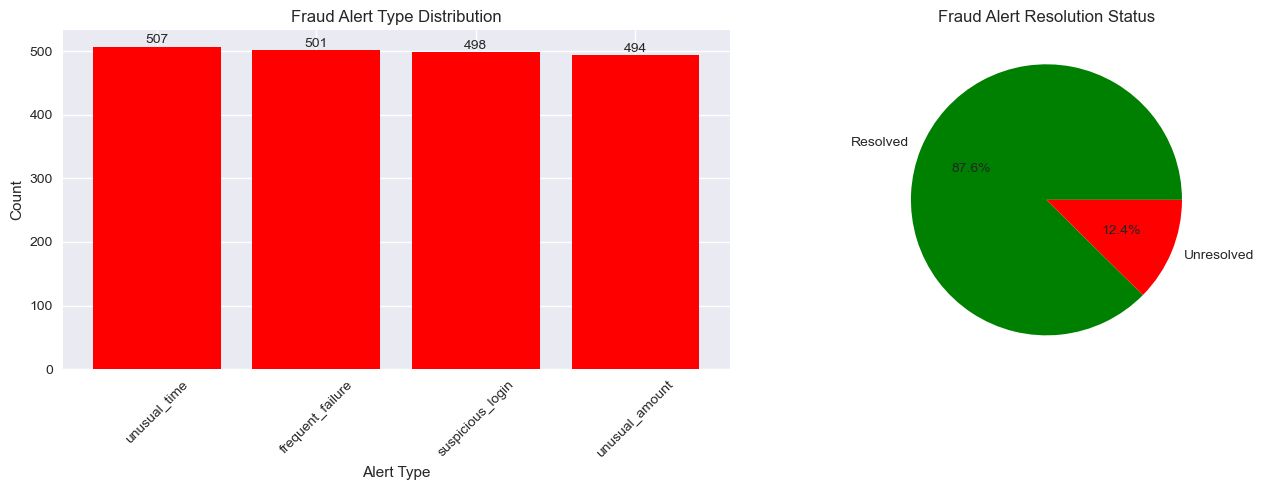

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alert type distribution
alert_type = fraud_df['alert_type'].value_counts()
axes[0].bar(alert_type.index, alert_type.values, color='red')
axes[0].set_title('Fraud Alert Type Distribution')
axes[0].set_xlabel('Alert Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(alert_type.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Resolved vs Unresolved
resolved = fraud_df['resolved'].value_counts()
axes[1].pie(resolved.values,
            labels=['Resolved', 'Unresolved'],
            autopct='%1.1f%%',
            colors=['green', 'red'])
axes[1].set_title('Fraud Alert Resolution Status')

plt.tight_layout()
plt.savefig('fraud_alert_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

1️⃣2️⃣ Correlation Heatmap

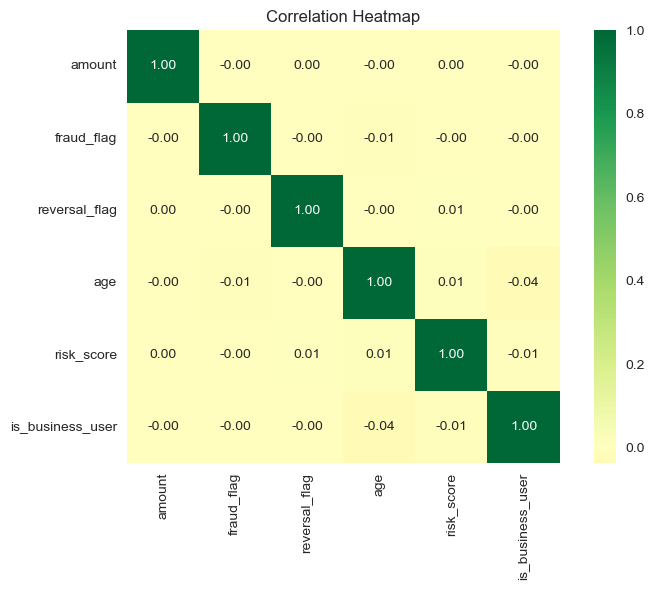

In [24]:
# Select numeric columns from transaction + customer merge
corr_df = transaction_df.merge(
    customer_df[['customer_id', 'age', 'risk_score', 'is_business_user']],
    on='customer_id', how='left'
)

# Select only numeric columns
numeric_cols = corr_df[['amount', 'fraud_flag', 'reversal_flag',
                         'age', 'risk_score', 'is_business_user']]

# Convert bool to int
numeric_cols = numeric_cols.copy()
numeric_cols['fraud_flag']       = numeric_cols['fraud_flag'].astype(int)
numeric_cols['reversal_flag']    = numeric_cols['reversal_flag'].astype(int)
numeric_cols['is_business_user'] = numeric_cols['is_business_user'].astype(int)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

1️⃣3️⃣ Failure Reason Distribution

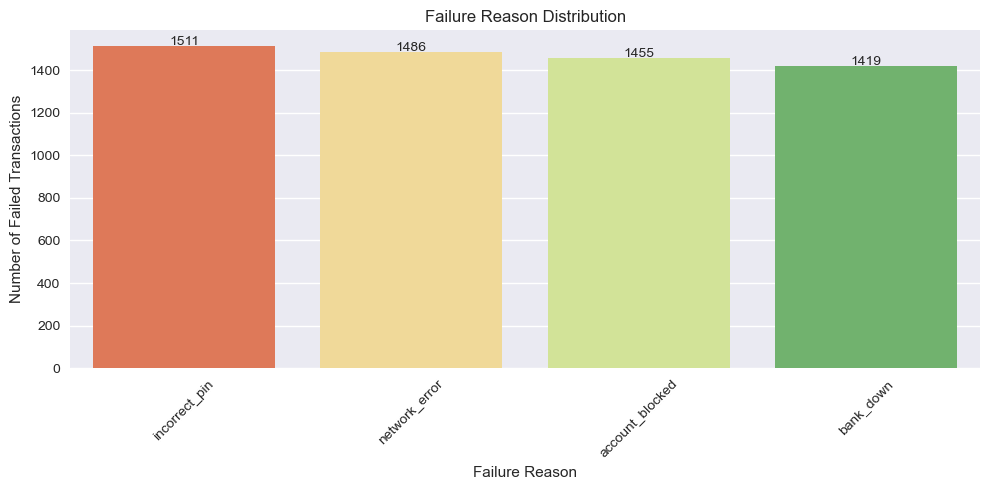

failure_reason
incorrect_pin      1511
network_error      1486
account_blocked    1455
bank_down          1419
Name: count, dtype: int64


In [25]:
# Failed transaction counts
failure_reason = transaction_df[
    transaction_df['status'] == 'failed'
]['failure_reason'].value_counts()

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    x=failure_reason.index,
    y=failure_reason.values,
    palette='RdYlGn'
)

# Labels on bars
for i, v in enumerate(failure_reason.values):
    plt.text(i, v + 5, str(v), ha='center')

plt.title('Failure Reason Distribution')
plt.xlabel('Failure Reason')
plt.ylabel('Number of Failed Transactions')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('failure_reason_distribution.png', dpi=150)
plt.show()

print(failure_reason)

## Statistical Analysis

In [26]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries ready!")

Libraries ready!


#### 1️⃣ T-Test — Do Fraud Transactions Have Higher Amounts?

In [27]:
# Separate fraud and non-fraud amounts
fraud_amount     = transaction_df[transaction_df['fraud_flag'] == True]['amount']
non_fraud_amount = transaction_df[transaction_df['fraud_flag'] == False]['amount']

# Run t-test
t_stat, p_value = stats.ttest_ind(fraud_amount, non_fraud_amount)

print("T-Test: Fraud vs Non-Fraud Amount")
print(f"Fraud Mean     : {fraud_amount.mean():.2f}")
print(f"Non-Fraud Mean : {non_fraud_amount.mean():.2f}")
print(f"P-Value        : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Fraud transactions have SIGNIFICANTLY different amounts")
else:
    print("Result: No significant difference in amounts")

T-Test: Fraud vs Non-Fraud Amount
Fraud Mean     : 42.36
Non-Fraud Mean : 42.42
P-Value        : 0.9355

Result: No significant difference in amounts


#### 2️⃣ T-Test — Do Rooted Devices Have Higher Transaction Amounts?

In [28]:
# Merge transaction with device
rooted_df = transaction_df.merge(
    device_df[['device_id', 'is_rooted']],
    on='device_id', how='left'
)

rooted_amount     = rooted_df[rooted_df['is_rooted'] == True]['amount']
non_rooted_amount = rooted_df[rooted_df['is_rooted'] == False]['amount']

t_stat, p_value = stats.ttest_ind(rooted_amount, non_rooted_amount)

print("T-Test: Rooted vs Non-Rooted Device Amount")
print(f"Rooted Mean     : {rooted_amount.mean():.2f}")
print(f"Non-Rooted Mean : {non_rooted_amount.mean():.2f}")
print(f"P-Value         : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Rooted devices have SIGNIFICANTLY different transaction amounts")
else:
    print("Result: No significant difference in amounts")

T-Test: Rooted vs Non-Rooted Device Amount
Rooted Mean     : 41.86
Non-Rooted Mean : 42.44
P-Value         : 0.3544

Result: No significant difference in amounts


#### 3️⃣ ANOVA — Do Transaction Amounts Differ by Region?

In [29]:
# Merge with customer to get region
region_df = transaction_df.merge(
    customer_df[['customer_id', 'region']],
    on='customer_id', how='left'
)

# Separate by region
north  = region_df[region_df['region'] == 'north']['amount']
south  = region_df[region_df['region'] == 'south']['amount']
east   = region_df[region_df['region'] == 'east']['amount']
west   = region_df[region_df['region'] == 'west']['amount']
central = region_df[region_df['region'] == 'central']['amount']

f_stat, p_value = stats.f_oneway(north, south, east, west, central)

print("ANOVA: Transaction Amount by Region")
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Transaction amounts SIGNIFICANTLY differ across regions")
else:
    print("Result: No significant difference across regions")

print("\nMean Amount by Region:")
print(region_df.groupby('region')['amount'].mean().round(2))

ANOVA: Transaction Amount by Region
F-Statistic : 0.3508
P-Value     : 0.8436

Result: No significant difference across regions

Mean Amount by Region:
region
central    42.49
east       42.53
north      42.21
south      42.54
west       42.33
Name: amount, dtype: float64


#### 4️⃣ Chi-Square — Is Fraud Associated with Channel?

In [30]:
# Create contingency table
contingency = pd.crosstab(
    transaction_df['channel'],
    transaction_df['fraud_flag']
)
print("Fraud Count by Channel:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nP-Value : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Channel IS associated with fraud")
else:
    print("Result: Channel is NOT associated with fraud")

Fraud Count by Channel:
fraud_flag  False  True 
channel                 
app         32692    673
intent      32727    629
qr_code     32581    698

P-Value : 0.1434

Result: Channel is NOT associated with fraud


#### 5️⃣ Chi-Square — Is Fraud Associated with Rooted Devices?

In [31]:
contingency = pd.crosstab(
    rooted_df['is_rooted'],
    rooted_df['fraud_flag']
)
print("Fraud Count by Rooted Status:")
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nP-Value : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Rooted devices ARE significantly associated with fraud")
else:
    print("Result: No significant association")

Fraud Count by Rooted Status:
fraud_flag  False  True 
is_rooted               
False       95485   1344
True         2515    656

P-Value : 0.0000

Result: Rooted devices ARE significantly associated with fraud


#### 6️⃣ Correlation — Does Risk Score Predict Fraud?

Correlation: Risk Score vs Fraud
Correlation : -0.0016
P-Value     : 0.6123

Result: Risk score is NOT significantly correlated with fraud


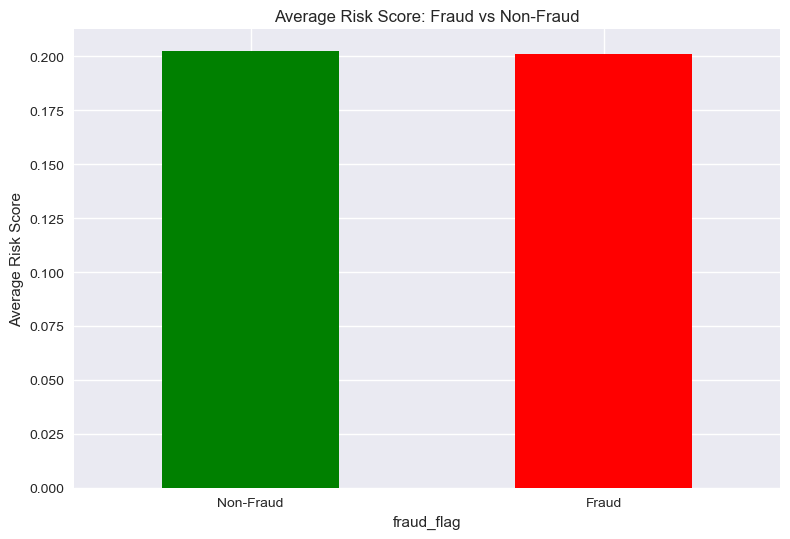

In [36]:
# Merge risk score with transactions
corr_df = transaction_df.merge(
    customer_df[['customer_id', 'risk_score']],
    on='customer_id', how='left'
)

corr, p_value = stats.pearsonr(
    corr_df['risk_score'],
    corr_df['fraud_flag'].astype(int)
)

print("Correlation: Risk Score vs Fraud")
print(f"Correlation : {corr:.4f}")
print(f"P-Value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: Risk score IS significantly correlated with fraud")
else:
    print("Result: Risk score is NOT significantly correlated with fraud")

# Simple visualization
corr_df.groupby('fraud_flag')['risk_score'].mean().plot(
    kind='bar', color=['green', 'red'],
    title='Average Risk Score: Fraud vs Non-Fraud'
)
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
plt.ylabel('Average Risk Score')
plt.tight_layout()
plt.savefig('risk_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

#### 7️⃣ Simple Summary Table

In [37]:
print("=" * 55)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 55)
print(f"{'Test':<35} {'Significant?'}")
print("-" * 55)

tests = [
    ("T-Test: Fraud vs Non-Fraud Amount", "Not Significant"),
    ("T-Test: Rooted vs Non-Rooted Amount", "Not Significant"),
    ("ANOVA: Amount by Region", "Not Significant"),
    ("Chi-Square: Fraud vs Channel", "Not Significant"),
    ("Chi-Square: Fraud vs Rooted Device", "Significant"),
    ("Correlation: Risk Score vs Fraud", "Not Significant"),
]

for test, result in tests:
    print(f"{test:<35} {result}")

print("-" * 55)
print("Significance Level: p < 0.05 = Significant")

STATISTICAL ANALYSIS SUMMARY
Test                                Significant?
-------------------------------------------------------
T-Test: Fraud vs Non-Fraud Amount   Not Significant
T-Test: Rooted vs Non-Rooted Amount Not Significant
ANOVA: Amount by Region             Not Significant
Chi-Square: Fraud vs Channel        Not Significant
Chi-Square: Fraud vs Rooted Device  Significant
Correlation: Risk Score vs Fraud    Not Significant
-------------------------------------------------------
Significance Level: p < 0.05 = Significant
